In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
def rmse(Y_true, Y_pred):
    return np.sqrt(mean_squared_error(Y_true, Y_pred))
df = pd.read_csv("ToyotaCorolla - MLR.csv")
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [51]:
df.corr(numeric_only=True)

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
Price,1.000000,-0.876590,-0.569960,0.314990,0.033081,0.126389,0.185326,NaN,0.063104,0.581198
Age_08_04,-0.876590,1.000000,0.505672,-0.156622,0.031717,-0.098084,-0.148359,NaN,-0.005364,-0.470253
KM,-0.569960,0.505672,1.000000,-0.333538,-0.081854,0.102683,-0.036197,NaN,0.015023,-0.028598
HP,0.314990,-0.156622,-0.333538,1.000000,0.013144,0.035856,0.092424,NaN,0.209477,0.089614
Automatic,0.033081,0.031717,-0.081854,0.013144,1.000000,0.066740,-0.027654,NaN,-0.098555,0.057249
cc,0.126389,-0.098084,0.102683,0.035856,0.066740,1.000000,0.079903,NaN,0.014629,0.335637
Doors,0.185326,-0.148359,-0.036197,0.092424,-0.027654,0.079903,1.000000,NaN,-0.160141,0.302618
Cylinders,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gears,0.063104,-0.005364,0.015023,0.209477,-0.098555,0.014629,-0.160141,NaN,1.000000,0.020613
Weight,0.581198,-0.470253,-0.028598,0.089614,0.057249,0.335637,0.302618,NaN,0.020613,1.000000


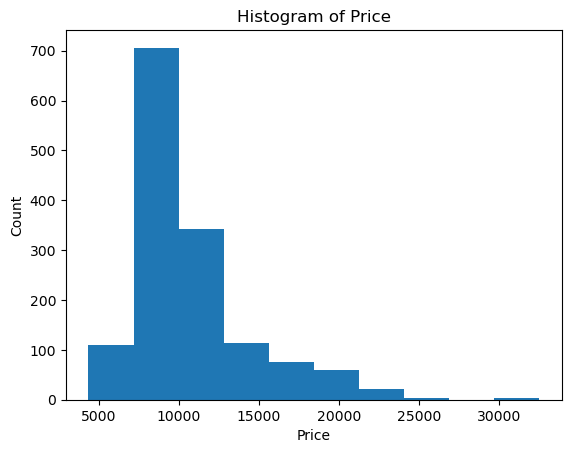

In [52]:
# 1 EDA(Exploratory Data Analysis)
plt.hist(df['Price'])
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Histogram of Price")
plt.show()

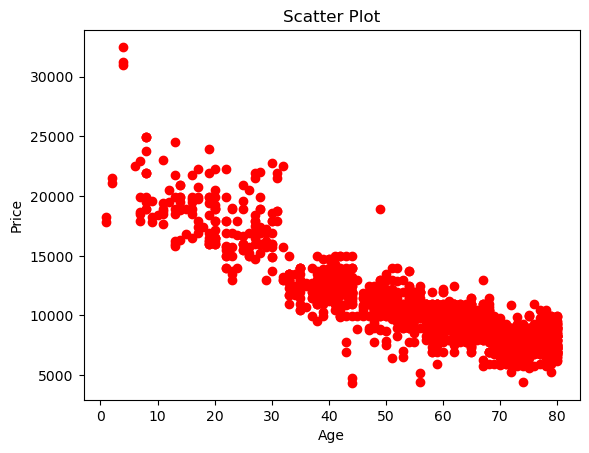

In [53]:
plt.scatter(x=df["Age_08_04"],y=df["Price"],color="red")
plt.xlabel("Age")
plt.ylabel("Price")
plt.title("Scatter Plot")
plt.show()

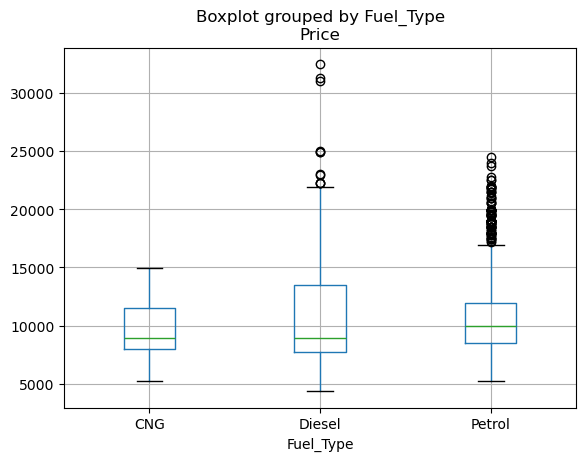

In [54]:
df.boxplot(column="Price",by="Fuel_Type")
plt.show()

In [55]:
# 2 Pre-processing
X = df.drop(columns=["Price"])
Y = df["Price"]
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_imputer = SimpleImputer(strategy="median")
X_num = pd.DataFrame(num_imputer.fit_transform(X[num_cols]), columns=num_cols)
ohe = OneHotEncoder(sparse_output=False, drop="first")
X_cat = pd.DataFrame(ohe.fit_transform(X[cat_cols]), columns=ohe.get_feature_names_out(cat_cols))
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_processed), columns=X_processed.columns)
X_processed = pd.concat([X_num_scaled, X_cat.reset_index(drop=True)], axis=1)
df_corr = pd.concat([X_processed, Y], axis=1)

In [56]:
# 3 Split in Train and Test Data sets
X_train, X_test, Y_train, Y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)
X_train_s, X_test_s, _, _ = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [57]:
# 4 Building Models
results = {}
# Model 1: Full features (unscaled)
lr1 = LinearRegression()
lr1.fit(X_train, Y_train)
Y_pred1 = lr1.predict(X_test)
results['Model 1 - Full (unscaled)'] = Y_pred1

# Model 2: Full features (scaled)
lr2 = LinearRegression()
lr2.fit(X_train_s, Y_train)
Y_pred2 = lr2.predict(X_test_s)
results['Model 2 - Full (scaled)'] = Y_pred2

# Model 3: Reduced features (top correlated ones)
top_feats = df_corr.corr()['Price'].abs().sort_values(ascending=False).index.drop('Price').tolist()[:5]
lr3 = LinearRegression()
lr3.fit(X_train[top_feats], Y_train)
Y_pred3 = lr3.predict(X_test[top_feats])
results['Model 3 - Reduced'] = Y_pred3


Model 1 - Full (unscaled):
RMSE: 1484.2654153296526
MAE: 990.887273919397
R²: 0.834888804061108

Model 2 - Full (scaled):
RMSE: 1484.2654153296526
MAE: 990.887273919397
R²: 0.834888804061108

Model 3 - Reduced:
RMSE: 1410.9208986586202
MAE: 998.9280802797807
R²: 0.8508034710291228


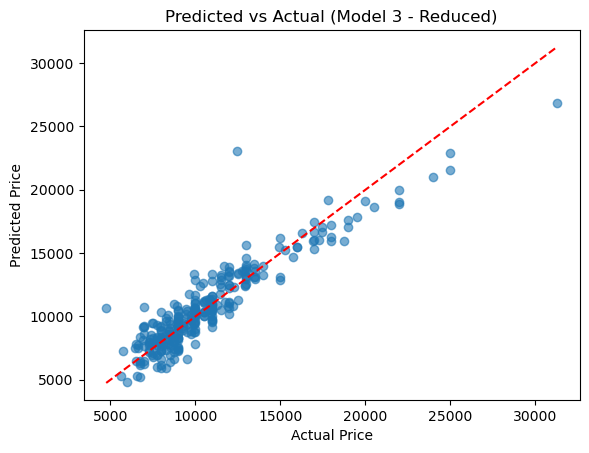

In [58]:
# 5 Evaluate Models
for name, preds in results.items():
    print(f"\n{name}:")
    print("RMSE:", rmse(Y_test, preds))
    print("MAE:", mean_absolute_error(y_test, preds))
    print("R²:", r2_score(Y_test, preds))

# Plot Predicted vs Actual for best model
best_model = min(results, key=lambda k: rmse(Y_test, results[k]))
plt.scatter(Y_test, results[best_model], alpha=0.6)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Predicted vs Actual ({best_model})")
plt.show()

In [59]:
# 6 Ridge & Lasso Regularization
alphas = {'alpha': [0.01, 0.1, 1, 10, 100]}
# Ridge
ridge = GridSearchCV(Ridge(), param_grid=alphas, scoring='neg_mean_squared_error', cv=5)
ridge.fit(X_train_s, Y_train)
print("Best Ridge alpha:", ridge.best_params_)
ridge_pred = ridge.predict(X_test_s)
print("Ridge RMSE:", rmse(Y_test, ridge_pred))
# Lasso
lasso = GridSearchCV(Lasso(max_iter=10000), param_grid=alphas, scoring='neg_mean_squared_error', cv=5)
lasso.fit(X_train_s, Y_train)
print("Best Lasso alpha:", lasso.best_params_)
lasso_pred = lasso.predict(X_test_s)
print("Lasso RMSE:", rmse(Y_test, lasso_pred))

Best Ridge alpha: {'alpha': 100}
Ridge RMSE: 1449.4168596516063
Best Lasso alpha: {'alpha': 100}
Lasso RMSE: 1428.2193028621932


In [ ]:
# Interview Questions
# 1) What is Normalization & Standardization and how is it helpful?
# ---> Normalization is used when we need to rescale the features between the range [0,1] to ensure values are on same scale when the data is being normalized.
# ---> Standardization is way to ensure data lies in normal distribution that means having mean zero and standard deviation of 1.

# 2) What techniques can be used to address multicollinearity in multiple linear regression?
# ---> a)Variance Inflation Factor (VIF): Calculate VIF for each feature and remove predictors with very high values (commonly VIF > 10).
# ---> b)Remove correlated features: Drop one of the variables if two features are highly correlated.
# ---> c)Principal Component Analysis (PCA): Convert correlated variables into uncorrelated components.
# ---> d)Regularization methods: Ridge regression shrinks coefficients of correlated variables, while Lasso regression can completely eliminate some predictors.

# Assumptions in Multiple Linear Regression :-
# 1)Linearity: Relationship between predictors and target is linear.
# 2)Independence of errors: Errors should not be correlated.
# 3)Homoscedasticity: Errors should have constant variance.
# 4)Normality of errors: Errors should be normally distributed.
# 5)No multicollinearity: Predictors should not be highly correlated.

#Implications:

#-->Violating these assumptions may lead to biased estimates, unstable coefficients, or unreliable predictions.